# RQ2 — Explainability: IEEE-CIS Fraud Detection Dataset

This notebook covers **RQ2**: can SHAP/LIME produce interpretable, transaction-level
red flags without materially hurting predictive performance — and does explanation
quality actually hold up (usefulness, stability), the way Chapter 2's literature
review says it's often *not* properly tested?

**Why IEEE-CIS and not the Credit Card dataset for this RQ:** the Credit Card
dataset's features (V1-V28) are PCA-transformed and anonymous — a SHAP value of
"V14 = -3.2 was the top driver" is not something an investigator can act on.
IEEE-CIS has partially named features (card type, email domain, address/distance
fields), so an explanation can read as "unusual purchase amount relative to this
card's history" instead of a meaningless PCA index.

**Scope note (deliberately lightweight):** this notebook uses only
`train_transaction.csv`, not the identity file join or full UID feature
engineering top Kaggle solutions use. The goal here is a clean, defensible
explainability study — not chasing leaderboard accuracy on this dataset. RQ1's
algorithm comparison was already answered in full on the Credit Card dataset;
here we train one strong model (XGBoost, the best cost/performance trade-off
from RQ1) and spend the effort on explainability instead of re-running the full
model grid.

**Dataset:** https://www.kaggle.com/competitions/ieee-fraud-detection/data
(only `train_transaction.csv` is needed — ignore `test_*.csv` and
`*_identity.csv`, and ignore `sample_submission.csv`; see the discussion in
chat about why the official test set has no usable labels for this thesis).


## 0. Setup

In [4]:
!pip install scikit-learn xgboost shap lime matplotlib seaborn joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=557b3afb701a5096288618414ca1c915c8df2b72dfda1dfbdb3f0cdc0d618fd9
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix,
)
import xgboost as xgb
import shap
from lime.lime_tabular import LimeTabularExplainer

sns.set_theme(style="whitegrid")

## 0.1 Config

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = Path('/content/drive/MyDrive/Bicocca/Thesis code')
DATA_PATH = BASE / 'data' / 'raw' / 'ieee_cis' / 'train_transaction.csv'

OUTDIR = BASE / 'results' / 'ieee_cis'
FIGDIR = OUTDIR / 'figures'
MODELDIR = OUTDIR / 'models'
for p in [OUTDIR, FIGDIR, MODELDIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Looking for data at:', DATA_PATH)
print('Exists:', DATA_PATH.exists())

N_SEEDS_STABILITY = 3   # how many retrains for the SHAP stability check (Section 6)
MAX_MISSING_FRAC = 0.50

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Looking for data at: /content/drive/MyDrive/Bicocca/Thesis code/data/raw/ieee_cis/train_transaction.csv
Exists: True


## 1. Load data and inspect

`TransactionDT` is a timedelta (not a real timestamp) but is monotonically
increasing — we use it for a chronological split, exactly as with the Credit
Card dataset, for the same leakage-avoidance reason.

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.3f}%  ({df['isFraud'].sum():,} / {len(df):,})")

missing_frac = df.isna().mean().sort_values(ascending=False)
print(f"\nColumns with >50% missing: {(missing_frac > 0.5).sum()} of {df.shape[1]}")
missing_frac.head(15)

Shape: (590540, 394)
Fraud rate: 3.499%  (20,663 / 590,540)

Columns with >50% missing: 174 of 394


,0
dist2,0.936284
D7,0.934099
D13,0.895093
D14,0.894695
D12,0.890410
D6,0.876068
D9,0.873123
D8,0.873123
V153,0.861237
V149,0.861237


## 2. Feature selection

We deliberately keep this simple: drop columns that are missing more than
`MAX_MISSING_FRAC` of the time, then keep a manageable, mostly-named subset
rather than all ~340 `V` columns (which would reintroduce the same
anonymized-feature problem we're using this dataset to avoid).

In [4]:
# Drop high-missingness columns
keep_cols = missing_frac[missing_frac <= MAX_MISSING_FRAC].index.tolist()
df_reduced = df[keep_cols].copy()
print(f"Kept {len(keep_cols)} of {df.shape[1]} columns after missingness filter")

# Named / interpretable columns we always want to keep if present
named_cols = [
    "TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "dist1", "dist2",
    "P_emaildomain", "R_emaildomain",
] + [c for c in df_reduced.columns if c.startswith("M")]
named_cols = [c for c in named_cols if c in df_reduced.columns]

# A small number of anonymized C/D/V columns that survived the missingness
# filter and showed up as informative in public analyses of this dataset
extra_numeric = [c for c in df_reduced.columns if c.startswith(("C", "D", "V"))][:15]

final_cols = list(dict.fromkeys(named_cols + extra_numeric))
df_model = df_reduced[final_cols].copy()
print(f"Final feature set: {len(final_cols) - 2} features (+ TransactionID, isFraud)")
print(df_model.dtypes.value_counts())

Kept 220 of 394 columns after missingness filter
Final feature set: 32 features (+ TransactionID, isFraud)
float64    21
object      9
int64       4
Name: count, dtype: int64


## 3. Preprocessing

- Categorical columns (`ProductCD`, `card4`, `card6`, email domains, `M1`-`M9`)
  are label-encoded, with a dedicated "missing" category rather than dropping
  rows.
- Numeric columns are median-imputed.
- Split chronologically by `TransactionDT` (70/10/20), same as the Credit Card
  pipeline, so RQ4-relevant conclusions stay comparable across datasets.

In [5]:
df_model = df_model.sort_values("TransactionDT").reset_index(drop=True)

categorical_cols = df_model.select_dtypes(include="object").columns.tolist()
numeric_cols = [c for c in df_model.columns
                if c not in categorical_cols + ["TransactionID", "isFraud"]]

print("Categorical columns:", categorical_cols)
print(f"Numeric columns: {len(numeric_cols)}")

encoders = {}
for col in categorical_cols:
    df_model[col] = df_model[col].fillna("missing").astype(str)
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

feature_cols = categorical_cols + numeric_cols

n = len(df_model)
n_test = int(n * 0.2)
n_val = int(n * 0.1)
n_train = n - n_test - n_val

train = df_model.iloc[:n_train]
val = df_model.iloc[n_train:n_train + n_val]
test = df_model.iloc[n_train + n_val:]

X_train, y_train = train[feature_cols], train["isFraud"]
X_val, y_val = val[feature_cols], val["isFraud"]
X_test, y_test = test[feature_cols], test["isFraud"]

print(f"\nTrain: {len(train):,} ({y_train.mean()*100:.3f}% fraud)")
print(f"Val:   {len(val):,} ({y_val.mean()*100:.3f}% fraud)")
print(f"Test:  {len(test):,} ({y_test.mean()*100:.3f}% fraud)")

Categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M4', 'M2', 'M1', 'M3', 'M6']
Numeric columns: 23

Train: 413,378 (3.517% fraud)
Val:   59,054 (3.490% fraud)
Test:  118,108 (3.441% fraud)


## 4. Train the model

XGBoost only, under two conditions (no handling, class weighting) — RQ1's
full model/strategy grid was already answered on the Credit Card dataset;
repeating it here would cost time without answering a new question. What
matters for RQ2 is having one strong, representative model to explain.

In [6]:
def train_xgb(X_tr, y_tr, use_class_weight, seed=42):
    fraud_ratio = y_tr.mean()
    spw = (1 - fraud_ratio) / fraud_ratio if use_class_weight else 1
    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=spw, eval_metric="aucpr",
        random_state=seed, n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    return model


def evaluate(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_score = model.predict_proba(X_te)[:, 1]
    return {
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_te, y_score),
        "roc_auc": roc_auc_score(y_te, y_score),
    }, y_pred, y_score


results = []
models = {}
for use_cw in [False, True]:
    label = "class_weight" if use_cw else "none"
    t0 = time.time()
    model = train_xgb(X_train, y_train, use_cw)
    train_time = time.time() - t0
    metrics, y_pred, y_score = evaluate(model, X_test, y_test)
    metrics.update({"strategy": label, "train_time_s": train_time})
    results.append(metrics)
    models[label] = model
    print(f"{label}: precision={metrics['precision']:.3f} recall={metrics['recall']:.3f} "
          f"f1={metrics['f1']:.3f} pr_auc={metrics['pr_auc']:.3f} roc_auc={metrics['roc_auc']:.3f}")

results_df = pd.DataFrame(results)
results_df.to_csv(OUTDIR / "rq2_baseline_results.csv", index=False)
results_df

none: precision=0.678 recall=0.138 f1=0.229 pr_auc=0.309 roc_auc=0.856
class_weight: precision=0.196 recall=0.545 f1=0.288 pr_auc=0.290 roc_auc=0.850


,precision,recall,f1,pr_auc,roc_auc,strategy,train_time_s
0,0.678398,0.137549,0.228723,0.308628,0.855771,none,15.924212
1,0.195535,0.545276,0.287848,0.289864,0.850413,class_weight,17.221061


## 5. SHAP analysis

We use the best-performing configuration by F1 from Section 4. `TreeExplainer`
is exact and fast for XGBoost (no sampling approximation needed).

In [7]:
best_label = results_df.loc[results_df["f1"].idxmax(), "strategy"]
best_model = models[best_label]
print(f"Explaining: XGBoost + {best_label}")

explainer = shap.TreeExplainer(best_model)
# Use a sample of the test set for the summary plot (SHAP on the full test set
# is unnecessary and slow); individual case explanations later use the full,
# specific rows we care about.
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]
shap_values = explainer.shap_values(X_sample)

Explaining: XGBoost + class_weight


## 5.1 SHAP summary plot (global feature impact)

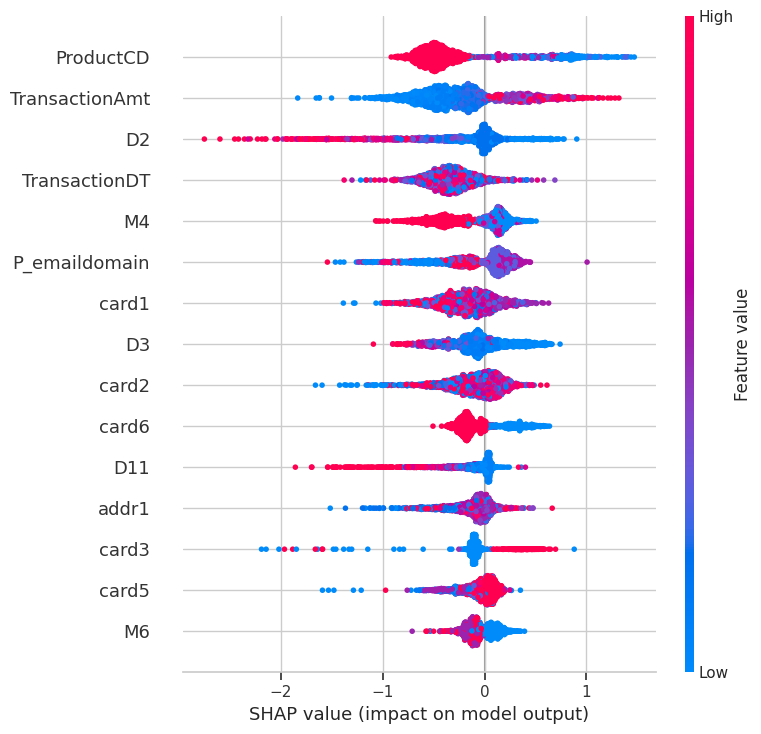

In [8]:
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGDIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.2 SHAP mean |value| bar chart (which features matter most, on average)

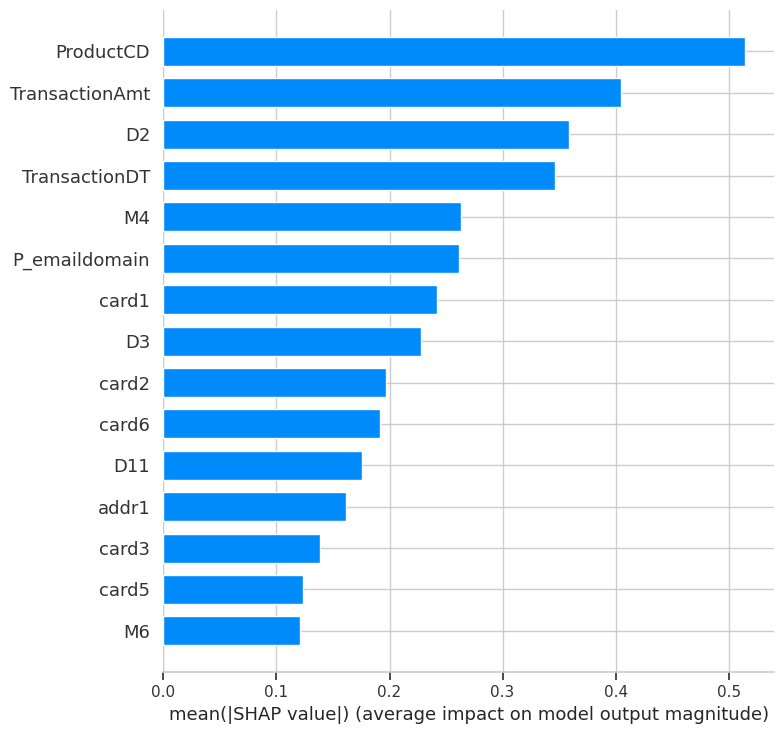

In [9]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGDIR / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.3 Individual red-flag example (waterfall plot)

This is the concrete deliverable the original thesis proposal promised:
an interpretable, transaction-level explanation an investigator could
actually read. We pick one true-positive fraud case (correctly flagged)
from the test set.

2216 true-positive fraud cases in the test set


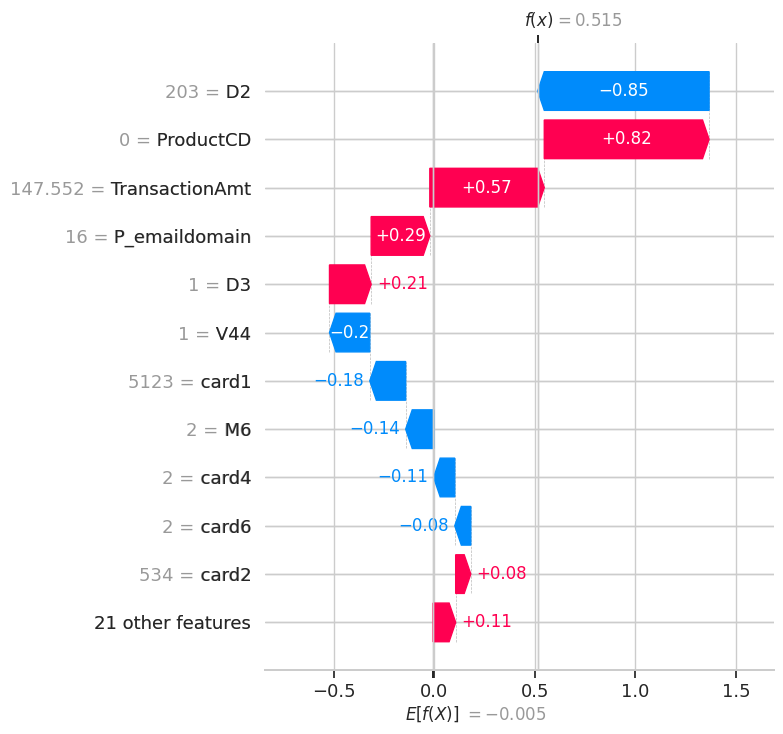


Raw feature values for this transaction:
                      472499
ProductCD       0.000000e+00
card4           2.000000e+00
card6           2.000000e+00
P_emaildomain   1.600000e+01
M4              2.000000e+00
M2              2.000000e+00
M1              2.000000e+00
M3              2.000000e+00
M6              2.000000e+00
TransactionDT   1.219677e+07
TransactionAmt  1.475520e+02
card1           5.123000e+03
card2           5.340000e+02
card3           1.500000e+02
card5           2.240000e+02
addr1           2.990000e+02
addr2           8.700000e+01
D2              2.030000e+02
V6              1.000000e+00
V1              1.000000e+00
V9              1.000000e+00
V10             0.000000e+00
V11             0.000000e+00
D11             4.300000e+01
V2              1.000000e+00
V7              1.000000e+00
V8              1.000000e+00
V5              1.000000e+00
V4              1.000000e+00
V3              1.000000e+00
D3              1.000000e+00
V44             1.000000e+00


In [10]:
y_pred_test = best_model.predict(X_test)
true_positive_idx = np.where((y_test.values == 1) & (y_pred_test == 1))[0]
print(f"{len(true_positive_idx)} true-positive fraud cases in the test set")

if len(true_positive_idx) > 0:
    case_idx = true_positive_idx[0]
    case_row = X_test.iloc[[case_idx]]

    case_shap = explainer(case_row)
    shap.plots.waterfall(case_shap[0], show=False, max_display=12)
    plt.tight_layout()
    plt.savefig(FIGDIR / "shap_waterfall_example.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nRaw feature values for this transaction:")
    print(case_row.T)
else:
    print("No true positives found in this sample - widen the search or pick from all test predictions.")

## 6. LIME analysis on the same case

LIME approximates the model locally with a simple linear model around one
instance. Comparing it side by side with the SHAP waterfall above tells us
whether the two methods agree on what drove this specific prediction - which
is itself part of RQ2 (does the explanation actually hold up, or is it
method-dependent?).

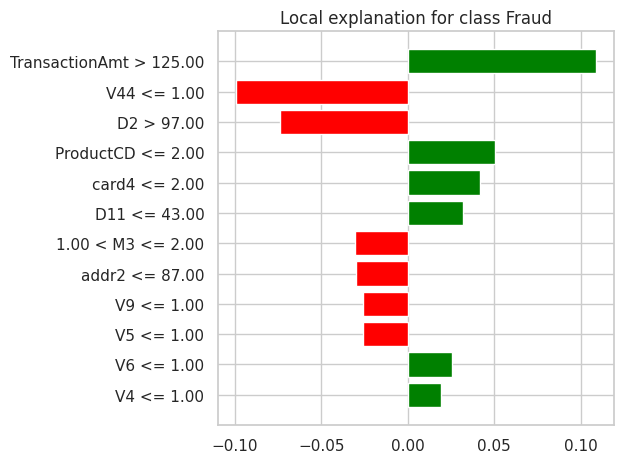

LIME's top features for this case:
  TransactionAmt > 125.00: +0.1088
  V44 <= 1.00: -0.0996
  D2 > 97.00: -0.0736
  ProductCD <= 2.00: +0.0503
  card4 <= 2.00: +0.0415
  D11 <= 43.00: +0.0318
  1.00 < M3 <= 2.00: -0.0304
  addr2 <= 87.00: -0.0297
  V9 <= 1.00: -0.0261
  V5 <= 1.00: -0.0260
  V6 <= 1.00: +0.0253
  V4 <= 1.00: +0.0194


In [11]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    class_names=["Legit", "Fraud"],
    mode="classification",
    random_state=42,
)

if len(true_positive_idx) > 0:
    lime_exp = lime_explainer.explain_instance(
        case_row.values[0],
        best_model.predict_proba,
        num_features=12,
    )
    lime_exp.as_pyplot_figure()
    plt.tight_layout()
    plt.savefig(FIGDIR / "lime_example.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("LIME's top features for this case:")
    for feat, weight in lime_exp.as_list():
        print(f"  {feat}: {weight:+.4f}")

## 7. Explanation stability check

Chapter 2 raised a specific, well-documented concern: SHAP/LIME explanations
can shift across retraining runs even when nothing about the modeling
decision changes. Here we retrain XGBoost with `N_SEEDS_STABILITY` different
random seeds (same data, same hyperparameters, only the seed changes) and
check how much the *global* top-10 SHAP feature ranking moves between runs.

We use Jaccard similarity between each pair of top-10 sets: 1.0 means
identical top-10 features, 0.0 means no overlap at all.

In [12]:
def top_k_shap_features(model, X_sample, k=10):
    expl = shap.TreeExplainer(model)
    sv = expl.shap_values(X_sample)
    mean_abs = np.abs(sv).mean(axis=0)
    top_k_idx = np.argsort(mean_abs)[::-1][:k]
    return set(X_sample.columns[top_k_idx])


def jaccard(a, b):
    return len(a & b) / len(a | b)


top_feature_sets = []
for seed in range(N_SEEDS_STABILITY):
    m = train_xgb(X_train, y_train, use_class_weight=(best_label == "class_weight"), seed=seed)
    top_feats = top_k_shap_features(m, X_sample, k=10)
    top_feature_sets.append(top_feats)
    print(f"seed {seed} top-10: {sorted(top_feats)}")

pairwise_scores = []
for i in range(len(top_feature_sets)):
    for j in range(i + 1, len(top_feature_sets)):
        score = jaccard(top_feature_sets[i], top_feature_sets[j])
        pairwise_scores.append(score)
        print(f"Jaccard(seed {i}, seed {j}) = {score:.3f}")

print(f"\nMean pairwise Jaccard similarity: {np.mean(pairwise_scores):.3f}")
print("(1.0 = perfectly stable top-10 across retrains, 0.0 = no overlap at all)")

seed 0 top-10: ['D2', 'D3', 'M4', 'P_emaildomain', 'ProductCD', 'TransactionAmt', 'TransactionDT', 'card1', 'card2', 'card6']
seed 1 top-10: ['D2', 'D3', 'M4', 'P_emaildomain', 'ProductCD', 'TransactionAmt', 'TransactionDT', 'card1', 'card2', 'card6']
seed 2 top-10: ['D2', 'D3', 'M4', 'P_emaildomain', 'ProductCD', 'TransactionAmt', 'TransactionDT', 'card1', 'card2', 'card6']
Jaccard(seed 0, seed 1) = 1.000
Jaccard(seed 0, seed 2) = 1.000
Jaccard(seed 1, seed 2) = 1.000

Mean pairwise Jaccard similarity: 1.000
(1.0 = perfectly stable top-10 across retrains, 0.0 = no overlap at all)


## 8. Save everything for Chapter 4 (RQ2 section)

- `rq2_baseline_results.csv` — predictive performance of the explained model
- `figures/` — SHAP summary, SHAP bar, SHAP waterfall (individual case), LIME
  explanation for the same case
- Stability scores are printed above; copy the mean Jaccard value into your
  results table by hand, or extend this cell to also save it to CSV.

In [13]:
joblib.dump(best_model, MODELDIR / f"xgb_{best_label}.joblib")

stability_df = pd.DataFrame({
    "pair": [f"seed_{i}_vs_seed_{j}" for i in range(len(top_feature_sets))
             for j in range(i + 1, len(top_feature_sets))],
    "jaccard_similarity": pairwise_scores,
})
stability_df.to_csv(OUTDIR / "rq2_shap_stability.csv", index=False)

print("Saved:")
print(f"  {OUTDIR / 'rq2_baseline_results.csv'}")
print(f"  {OUTDIR / 'rq2_shap_stability.csv'}")
print(f"  {FIGDIR} (4 figures)")
print(f"  {MODELDIR / f'xgb_{best_label}.joblib'}")

Saved:
  /content/drive/MyDrive/Bicocca/Thesis code/results/ieee_cis/rq2_baseline_results.csv
  /content/drive/MyDrive/Bicocca/Thesis code/results/ieee_cis/rq2_shap_stability.csv
  /content/drive/MyDrive/Bicocca/Thesis code/results/ieee_cis/figures (4 figures)
  /content/drive/MyDrive/Bicocca/Thesis code/results/ieee_cis/models/xgb_class_weight.joblib
